# Infraslow sigma-power oscillation — full pipeline across a control cohort

Runs the whole `infraslow` pipeline on **10 Bioserenity control subjects** and produces
**grand-average** figures. Every grand average follows the same rule:

> **average within each subject over its epochs, then average across subjects** —
> so each subject is weighted equally regardless of recording length.

Figures produced:

1. **Grand-average full-night spectrogram** (`plot_spectrogram_grand_average`) — a 2D
   time-warped average map plus a companion mean power spectrum (± SEM).
2. **Grand-average infraslow (~0.02 Hz) spectrum of sigma power**
   (`plot_infraslow_spectra_grand_average`) — the continuous-EEG reference vs. the
   YASA / Luna spindle-rate spectra.
3. **Grand-average spindle-epoch sigma spectrum**, YASA vs. Luna
   (`plot_spindle_sigma_spectra_grand_average`).

> ⚠️ Run on a **compute node** (needs `lunapi`, `yasa`, and `$OAK` data) — not the login
> node. Grab one with `sh_dev` / `salloc` first.

## 1. Setup

In [1]:
from infraslow import BioserenityPSGLoader
from infraslow.processing.detection import detect_subjects_spindles
from infraslow.processing.detection_luna import spindles_detect_luna
from infraslow.processing.infraslow import (
    sigma_infraslow_oscillation,
    spindle_infraslow_oscillation,
    average_spindle_spectrum,
)
from infraslow.viz import (
    plot_spectrogram_grand_average,
    plot_infraslow_spectra_grand_average,
    plot_spindle_sigma_spectra_grand_average,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Cohort: 10 control subjects (subject_id -> group).
SUBJECTS = {
    "318679": "control",
    "318769": "control",
    "318919": "control",
    "319018": "control",
    "319040": "control",
    "319046": "control",
    "319061": "control",
    "319076": "control",
    "319113": "control",
    "319118": "control",
}

SF = 128.0                 # common resample rate (Hz) for every subject
CHANNEL = "C3"             # analysis channel (same for envelope + both detectors)
REQUESTED = ["C3", "C4"]   # canonical channels to resolve per subject
INCLUDE = (2, 3)           # detect spindles within NREM (N2 + N3)

## 2. Load every subject

Build one loader per subject and load it; subjects that fail to load are skipped so the batch never aborts on one bad recording.

In [3]:
loaders = {}
for sid in SUBJECTS:
    try:
        loaders[sid] = BioserenityPSGLoader(
            subject_id=sid, sf=SF, requested_channels=REQUESTED
        ).load()
    except Exception as exc:  # missing EDF, unresolved channel, etc.
        print(f"skip {sid}: {exc}")

print(f"Loaded {len(loaders)}/{len(SUBJECTS)} subjects: {list(loaders)}")

initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7ff73c07bb30> 



  *** warning, signal 13 ( TFlo ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 14 ( CFlo ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 15 ( Tho ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 1

initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7ff73c07bb30> 



___________________________________________________________________
Processing: 318769 | /oak/stanford/groups/mignot/psg/Bioserenity/edf/318769.edf
 duration 07.48.36, 28116s | time 22.08.01 - 05.56.37 | date 01.01.12

 signals: 29 (of 29) selected in an EDF+C file
  F3 | F4 | C3 | C4 | O1 | O2 | LOC | ROC
  ECG | emg_Chin | emg_RLeg | emg_LLeg | Tho | Abd | SpO2 | flow_PFlo
  flow_TFlo | flow_CFlo | PPG | Snore | imp | rr | Leak | EPAP
  IPAP | Body | sao2 | HR | EDF Annotations
  extracting 'EDF Annotations' track from EDF+


initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7ff73c07bb30> 



...

initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7ff73c07bb30> 



___________________________________________________________________
Processing: 319113 | /oak/stanford/groups/mignot/psg/Bioserenity/edf/319113.edf
 duration 07.18.49, 26329s | time 21.55.36 - 05.14.25 | date 01.01.12

 signals: 27 (of 27) selected in an EDF+C file
  F3 | F4 | C3 | C4 | O1 | O2 | LOC | ROC
  ECG | emg_Chin | emg_RLeg | emg_LLeg | Tho | Abd | SpO2 | flow_PFlo
  flow_TFlo | flow_CFlo | Snore | IPAP | EPAP | Leak | Body | Pulse
  sao2 | HR | EDF Annotations
  extracting 'EDF Annotations' track from EDF+


initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7ff73c07bb30> 



___________________________________________________________________
Processing: 319118 | /oak/stanford/groups/mignot/psg/Bioserenity/edf/319118.edf
 duration 06.32.08, 23528s | time 23.11.29 - 05.43.37 | date 01.01.12

 signals: 28 (of 28) selected in an EDF+C file
  F3 | F4 | C3 | C4 | O1 | O2 | LOC | ROC
  ECG | emg_Chin | emg_RLeg | emg_LLeg | Tho | Abd | SpO2 | flow_PFlo
  flow_TFlo | flow_CFlo | Snore | imp | rr | Leak | EPAP | IPAP
  Body | sao2 | HR | EDF Annotations
  extracting 'EDF Annotations' track from EDF+


Loaded 10/10 subjects: ['318679', '318769', '318919', '319018', '319040', '319046', '319061', '319076', '319113', '319118']


## 3. Detect spindles (YASA & Luna)

YASA via the batch runner `detect_subjects_spindles`; Luna in a parallel loop with the same channel/stage settings, so the two detectors are directly comparable.

In [4]:
# YASA — one call for the whole cohort -> {subject_id: SpindlesResult|None}.
yasa_results = detect_subjects_spindles(
    loaders.values(), channel=CHANNEL, include=INCLUDE
)

# Luna — same settings, per subject.
luna_results = {}
for sid, loader in loaders.items():
    try:
        luna_results[sid] = spindles_detect_luna(
            loader, ch_names=CHANNEL, include=INCLUDE
        )
    except Exception as exc:
        print(f"Luna failed for {sid}: {exc}")
        luna_results[sid] = None

02-Jul-26 16:09:06 | WARNING | Hypnogram is SHORTER than data by 30.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.
02-Jul-26 16:09:09 | WARNING | Hypnogram is SHORTER than data by 6.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


Subject 318679: 293 spindle(s) detected on C3.


02-Jul-26 16:09:11 | WARNING | Hypnogram is SHORTER than data by 23.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


Subject 318769: 50 spindle(s) detected on C3.


02-Jul-26 16:09:13 | WARNING | Hypnogram is SHORTER than data by 18.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


...

Subject 319061: 453 spindle(s) detected on C3.


02-Jul-26 16:09:24 | WARNING | Hypnogram is SHORTER than data by 19.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


Subject 319076: 27 spindle(s) detected on C3.


02-Jul-26 16:09:26 | WARNING | Hypnogram is SHORTER than data by 8.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


Subject 319113: 37 spindle(s) detected on C3.
Subject 319118: 319 spindle(s) detected on C3.


## 4. Per-subject spectra (the *within-subject epoch average*)

For each subject we compute:

* **`sigma_specs`** — the detector-independent reference: the infraslow (~0.02 Hz)
  spectrum of the continuous **dB sigma-power envelope** (`sigma_infraslow_oscillation`).
* **`{yasa,luna}_iso`** — each detector's infraslow spectrum of its smooth spindle-rate
  series (`spindle_infraslow_oscillation`).
* **`{yasa,luna}_sigma`** — each detector's mean spindle-epoch power spectrum
  (`average_spindle_spectrum`).

Each of these is already averaged over that subject's epochs; the grand-average plots
below then average them across subjects.

In [5]:
sigma_specs, yasa_iso, luna_iso, yasa_sigma, luna_sigma = {}, {}, {}, {}, {}

def _peaks(result):
    if result is None or not len(result.summary()):
        return None
    return result.summary()["Peak"].to_numpy()

for sid, loader in loaders.items():
    data = np.asarray(loader.get_channel(CHANNEL), dtype=float)
    sf = float(loader.sf)
    duration_sec = len(data) / sf

    # Continuous-EEG infraslow reference (dB sigma-power envelope -> slow spectrum).
    sigma_specs[sid], _, _ = sigma_infraslow_oscillation(data, sf, smooth_sec=1.0)

    for store_iso, store_sigma, result in (
        (yasa_iso, yasa_sigma, yasa_results.get(sid)),
        (luna_iso, luna_sigma, luna_results.get(sid)),
    ):
        pk = _peaks(result)
        if pk is None:
            continue
        store_iso[sid], _, _ = spindle_infraslow_oscillation(pk, duration_sec=duration_sec)
        f, psd, _ = average_spindle_spectrum(data, sf, pk)
        store_sigma[sid] = (f, psd)

print(f"sigma:{len(sigma_specs)}  yasa_iso:{len(yasa_iso)}  luna_iso:{len(luna_iso)}")

sigma:10  yasa_iso:10  luna_iso:10


## 5. Grand-average spectrogram

Each subject's night is time-warped to a common relative-time axis and averaged (top); the companion panel is the across-subjects mean power spectrum ± SEM (bottom).

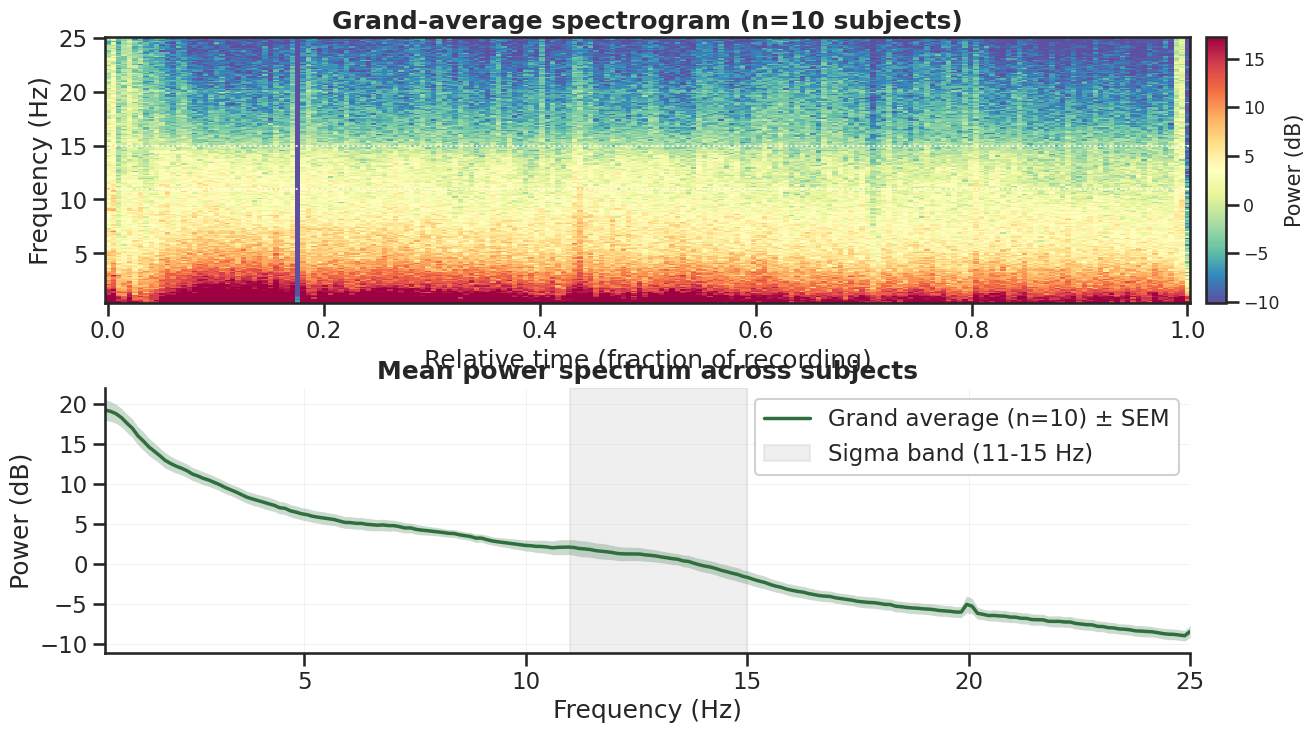

In [12]:
fig = plot_spectrogram_grand_average(
    loaders, channel=CHANNEL, fmin=0.5, fmax=25.0, win_sec=30.0
)
plt.show()

## 6. Grand-average infraslow oscillation of sigma power

The continuous-EEG reference and both detectors' spindle-rate spectra, grand-averaged across subjects with a SEM band. All three should peak in the shaded infraslow band (~0.02 Hz).

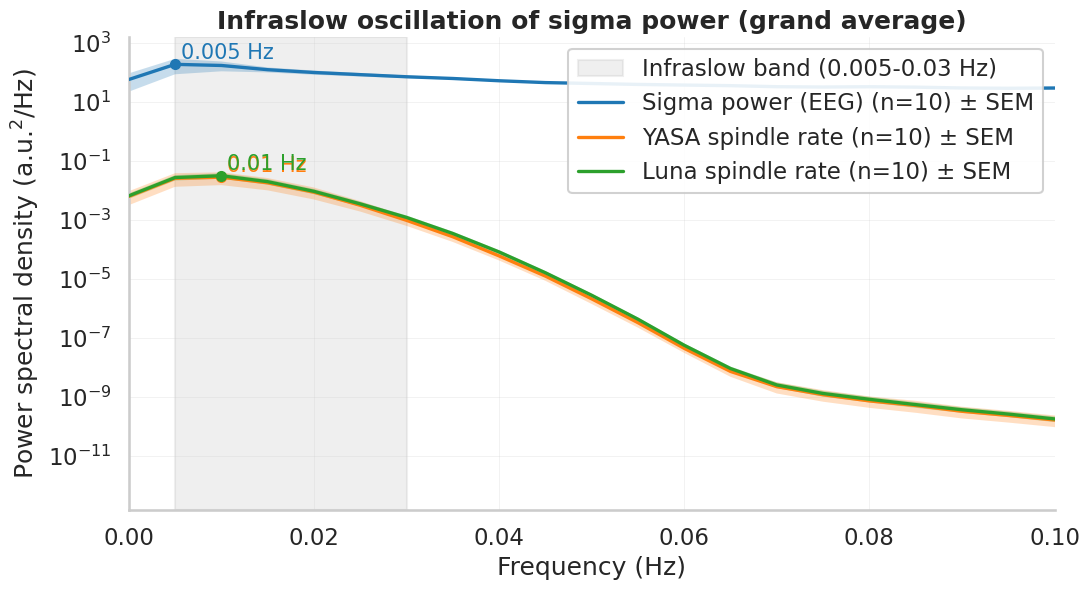

In [7]:
ax = plot_infraslow_spectra_grand_average(
    {
        "Sigma power (EEG)": sigma_specs,
        "YASA spindle rate": yasa_iso,
        "Luna spindle rate": luna_iso,
    },
    errorbar="sem",
    show_subjects=False,
)
ax.figure.set_size_inches(11, 6)
plt.tight_layout()
plt.show()

## 7. Grand-average spindle-epoch sigma spectrum

The companion high-frequency view: where in the sigma band each detector's spindles concentrate, grand-averaged across subjects.

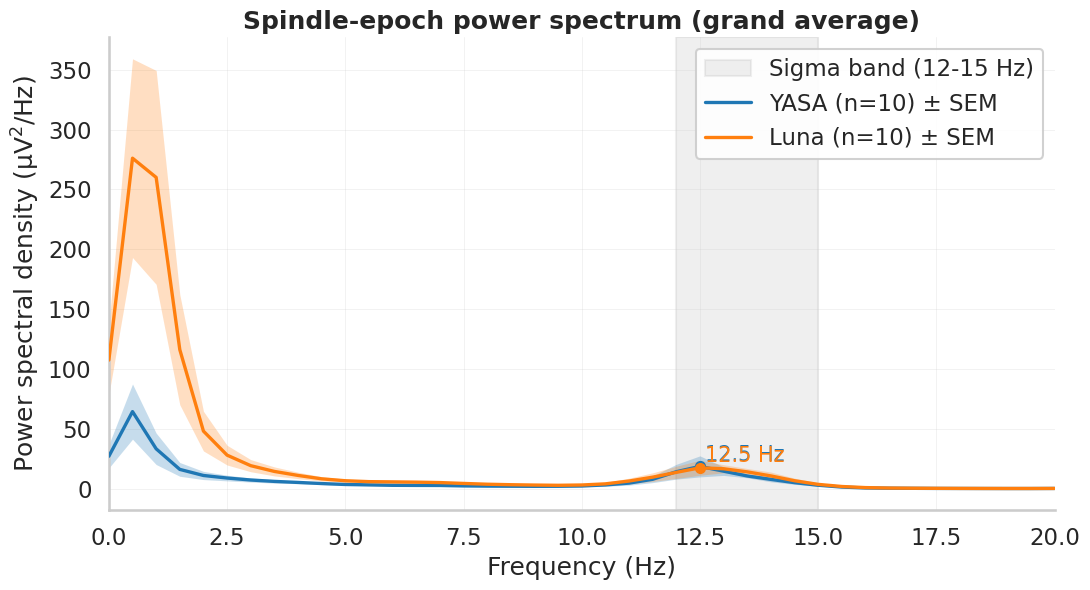

In [11]:
ax = plot_spindle_sigma_spectra_grand_average(
    {"YASA": yasa_sigma, "Luna": luna_sigma},
    errorbar="sem",
)
ax.figure.set_size_inches(11, 6)
plt.tight_layout()
plt.show()

## 8. Per-subject & group metrics

Infraslow peak frequency (in-band and whole-spectrum, the reference `get_iso` metric) and relative in-band power, per subject and averaged over the cohort.

In [9]:
rows = []
sources = [
    ("Sigma power (EEG)", sigma_specs),
    ("YASA spindle rate", yasa_iso),
    ("Luna spindle rate", luna_iso),
]
for source, specs in sources:
    for sid, spec in specs.items():
        rows.append({
            "subject": sid,
            "group": SUBJECTS[sid],
            "source": source,
            "peak_freq": spec.peak_freq,
            "full_peak_freq": spec.full_peak_freq,
            "rel_band_power": spec.rel_band_power,
        })

metrics = pd.DataFrame(rows)
display(metrics)

# Cohort summary: mean ± SEM per source.
summary = (
    metrics.groupby("source")[["peak_freq", "full_peak_freq", "rel_band_power"]]
    .agg(["mean", "sem"])
)
display(summary)

,subject,group,source,peak_freq,full_peak_freq,rel_band_power
0,318679,control,Sigma power (EEG),0.015,0.015,0.244061
1,318769,control,Sigma power (EEG),0.005,0.005,0.501408
2,318919,control,Sigma power (EEG),0.010,0.010,0.150381
3,319018,control,Sigma power (EEG),0.010,0.010,0.172854
4,319040,control,Sigma power (EEG),0.010,0.010,0.140229
5,319046,control,Sigma power (EEG),0.015,0.015,0.304097
6,319061,control,Sigma power (EEG),0.005,0.005,0.161151
7,319076,control,Sigma power (EEG),0.015,0.015,0.192933
8,319113,control,Sigma power (EEG),0.015,0.015,0.192954
9,319118,control,Sigma power (EEG),0.010,0.010,0.137764


peak_freq           full_peak_freq           rel_band_power  \
                       mean       sem           mean       sem           mean   
source                                                                          
Luna spindle rate    0.0095  0.000500         0.0095  0.000500       0.810757   
Sigma power (EEG)    0.0110  0.001247         0.0110  0.001247       0.219783   
YASA spindle rate    0.0100  0.000000         0.0100  0.000000       0.816755   

                             
                        sem  
source                       
Luna spindle rate  0.003797  
Sigma power (EEG)  0.035271  
YASA spindle rate  0.003676